Testing segmentation on: 1.3.6.1.4.1.14519.5.2.1.9688.9989.206846852338263339128528968856


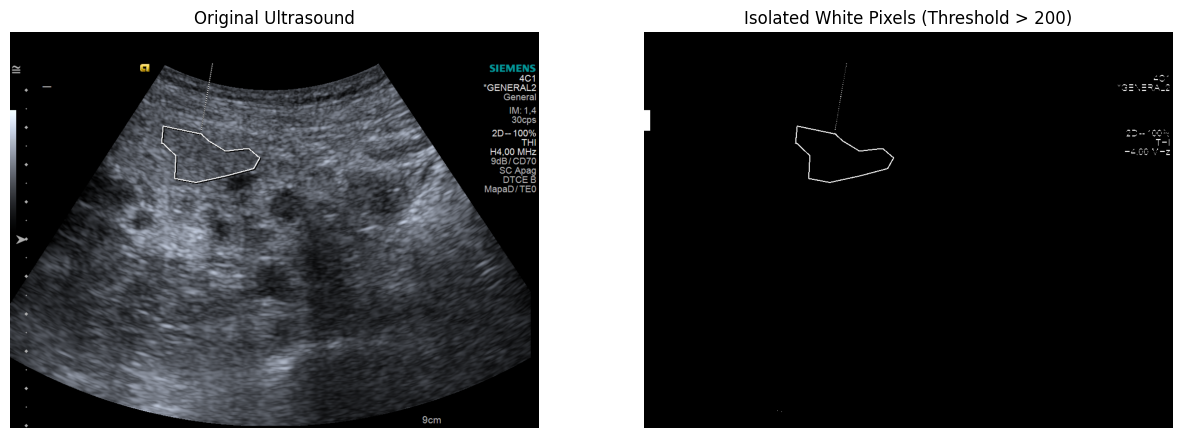

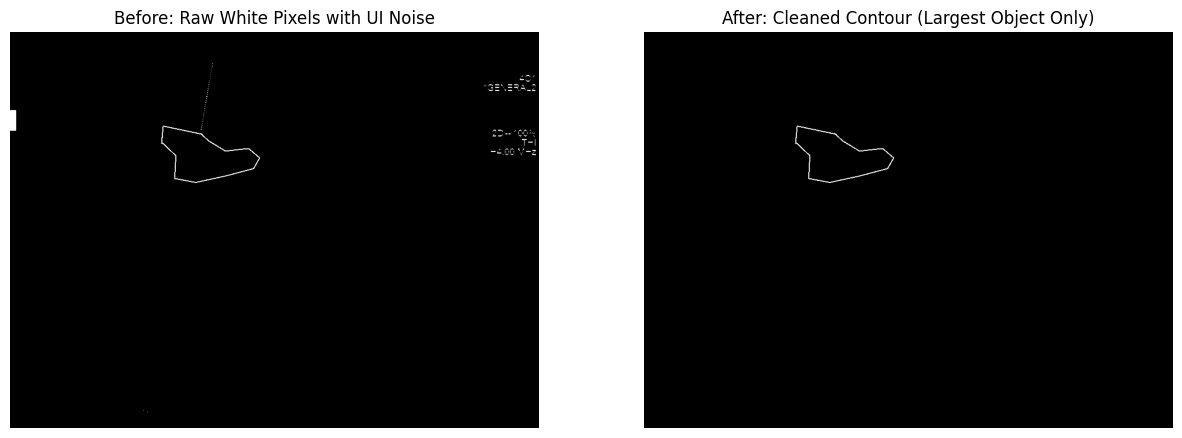

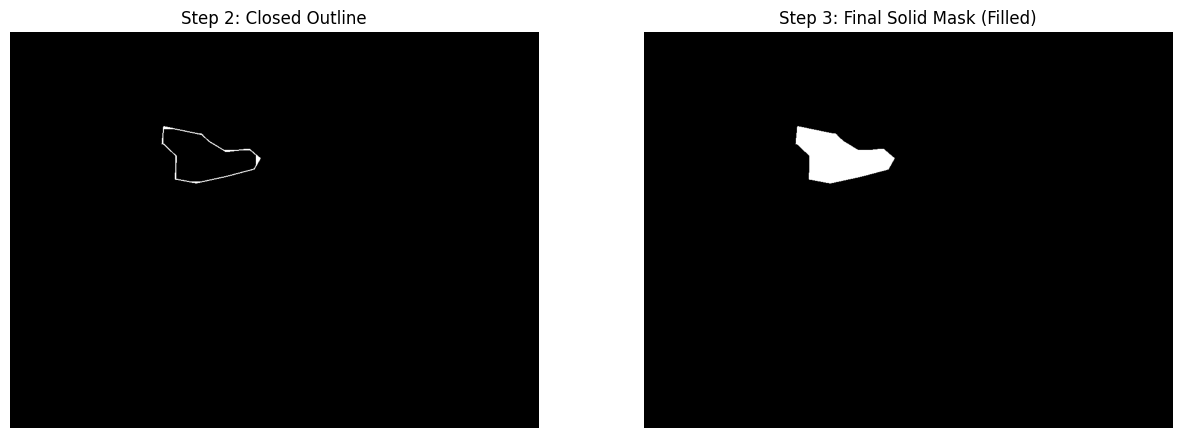

In [1]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2

test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "49_01", "20191106")

valid_files = [f for f in os.listdir(test_directory) if not f.startswith(".")]
file_path = os.path.join(test_directory, valid_files[0])

print(f"Testing segmentation on: {os.path.basename(file_path)}")

# dcmread unpacks the dicom images containing headers, patient data and raw scanner info
dataset = pydicom.dcmread(file_path)

# takes raw compressed binary data from dicom file and transltes it to a 2d numpy array of pixel values
image_rgb = dataset.pixel_array

# Define the threshold for "white"
# Color values range from 0 black to 255 white
color_threshold = 200
red_channel = image_rgb[:, :, 0]
green_channel = image_rgb[:, :, 1]
blue_channel = image_rgb[:, :, 2]

is_red_bright = red_channel > color_threshold
is_green_bright = green_channel > color_threshold
is_blue_bright = blue_channel > color_threshold

# A pixel must be bright in Red AND Green AND Blue to be considered white
white_pixels_mask = is_red_bright & is_green_bright & is_blue_bright

# Visualize the results
plt.figure(figsize=(15, 7))

# Plot Original
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Ultrasound")
plt.axis("off")

# Plot the Black and White Mask
plt.subplot(1, 2, 2)
plt.imshow(white_pixels_mask, cmap="gray")
plt.title(f"Isolated White Pixels (Threshold > {color_threshold})")
plt.axis("off")

plt.show()

# Convert the boolean mask (True/False) to an 8-bit image (255 for white, 0 for black)
# OpenCV requires this format
white_mask_8bit = (white_pixels_mask * 255).astype(np.uint8)

# Label every separate white object it finds with cv2
# function groups connected white pixels into islands and calculates their area
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
largest_label = 1
max_area = 0

# Loop through all found islands to find the one with the biggest area
for i in range(1, num_labels):
    # Get the area of the current island
    area = stats[i, cv2.CC_STAT_AREA]
    
    # If bigger than our current max remember this label
    if area > max_area:
        max_area = area
        largest_label = i

# Create a clean black image of the exact same size
clean_contour_mask = np.zeros_like(white_mask_8bit)

# Paint ONLY the largest island white on our new clean black image
clean_contour_mask[labels == largest_label] = 255

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(white_mask_8bit, cmap="gray")
plt.title("Before: Raw White Pixels with UI Noise")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("After: Cleaned Contour (Largest Object Only)")
plt.axis("off")

plt.show()

# Use morphological closing with a 20x20 kernel to bridge any gaps in the contour
kernel = np.ones((20, 20), np.uint8)
closed_contour_mask = cv2.morphologyEx(clean_contour_mask, cv2.MORPH_CLOSE, kernel)

# Trace boundary of white loop using the closed contour
# RETR_EXTERNAL means we only care about the outermost loop
contours, hierarchy = cv2.findContours(closed_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create new blank same-size black image
filled_mask = np.zeros_like(closed_contour_mask)

# Draw the contour and fill it with white
# thickness=cv2.FILLED equal to -1 used to fill in contour
cv2.drawContours(filled_mask, contours, contourIdx=-1, color=255, thickness=cv2.FILLED)

# Visualize the Final Mask
plt.figure(figsize=(15, 7))

# Plot the outline (Before)
plt.subplot(1, 2, 1)
plt.imshow(closed_contour_mask, cmap="gray")
plt.title("Step 2: Closed Outline")
plt.axis("off")

# Plot the filled solid mask (After)
plt.subplot(1, 2, 2)
plt.imshow(filled_mask, cmap="gray")
plt.title("Step 3: Final Solid Mask (Filled)")
plt.axis("off")

plt.show()